In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('vehicles.csv')
df.shape

(426880, 26)

In [7]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [8]:
df.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

In [9]:
# Drop columns we don't need
df = df.drop(columns=['county', 'url', 'region_url', 'image_url', 'description', 'VIN', 'id'])

# Keep only rows where our key columns have data
df = df.dropna(subset=['price', 'year', 'odometer', 'manufacturer', 'model'])

# Remove unrealistic prices (under $500 or over $100,000)
df = df[(df['price'] >= 500) & (df['price'] <= 100000)]

# Remove unrealistic odometer readings
df = df[(df['odometer'] > 1000) & (df['odometer'] < 300000)]

print(df.shape)

(353612, 19)


/var/folders/7f/z07x_z5914b3vghzbcp9g22h0000gn/T/ipykernel_57637/1220358281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.values, y=avg_price.index, palette='Blues_r')


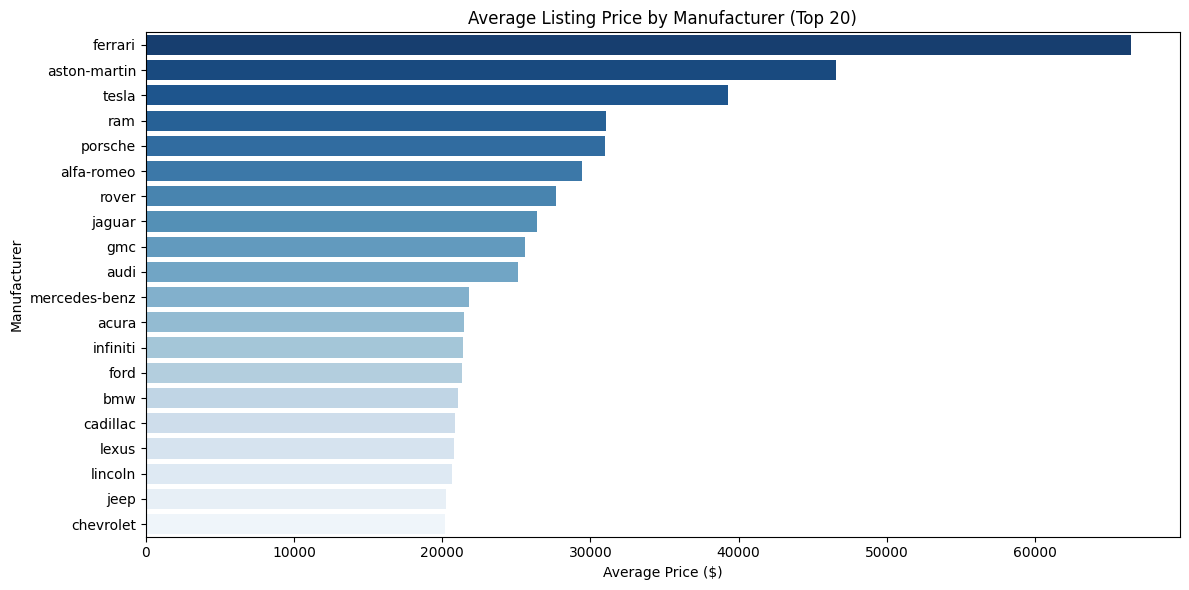

In [10]:
# Top 20 manufacturers by average price
avg_price = df.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=avg_price.values, y=avg_price.index, palette='Blues_r')
plt.title('Average Listing Price by Manufacturer (Top 20)')
plt.xlabel('Average Price ($)')
plt.ylabel('Manufacturer')
plt.tight_layout()
plt.show()

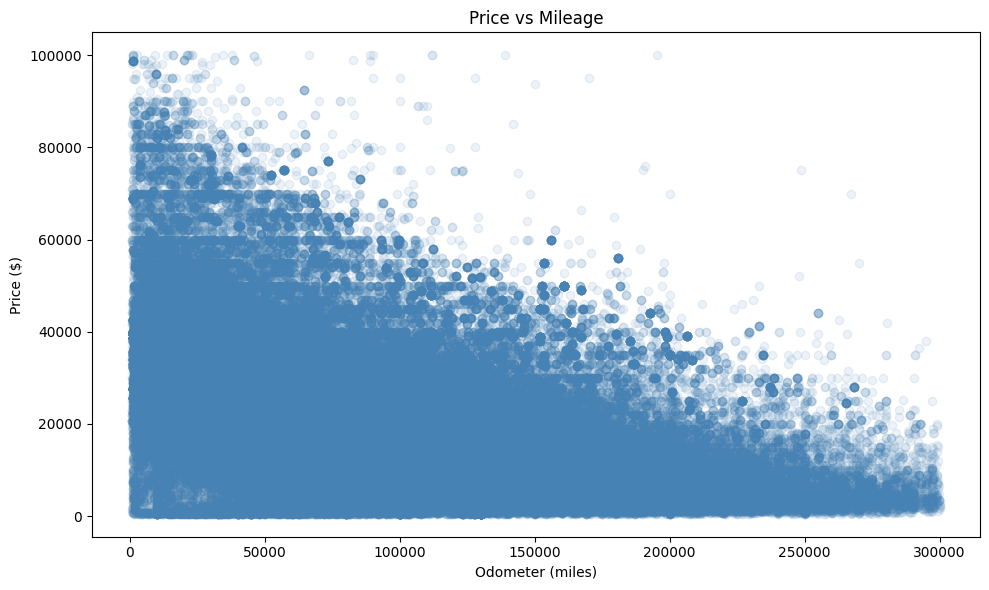

In [11]:
# How odometer affects price
plt.figure(figsize=(10,6))
plt.scatter(df['odometer'], df['price'], alpha=0.1, color='steelblue')
plt.title('Price vs Mileage')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

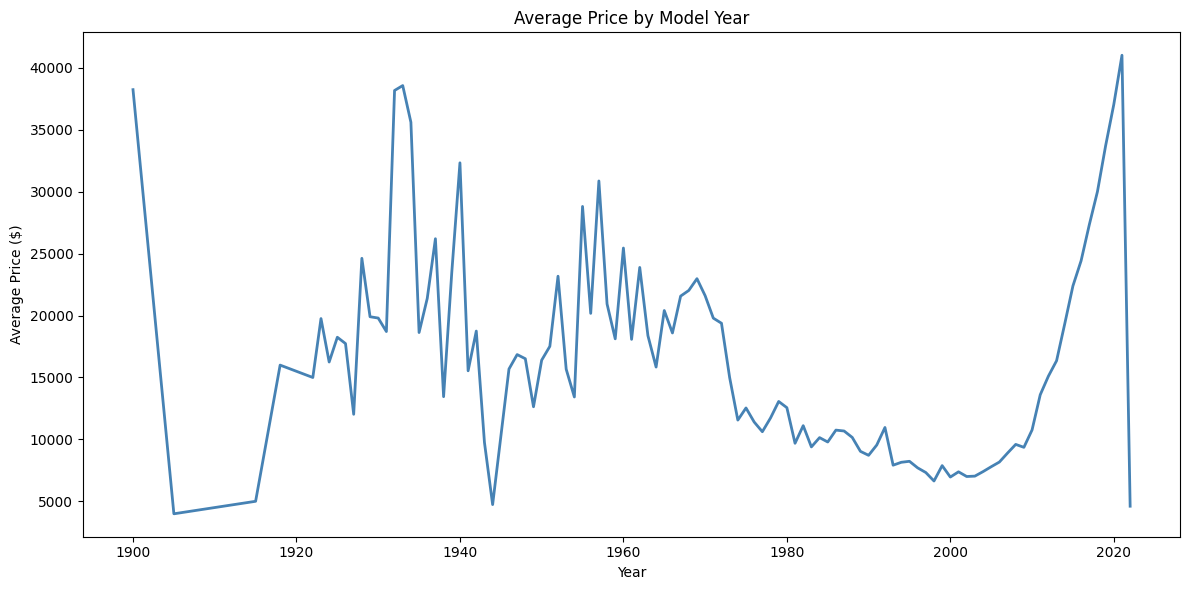

In [12]:
# How year affects price
avg_price_year = df.groupby('year')['price'].mean()

plt.figure(figsize=(12,6))
plt.plot(avg_price_year.index, avg_price_year.values, color='steelblue', linewidth=2)
plt.title('Average Price by Model Year')
plt.xlabel('Year')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

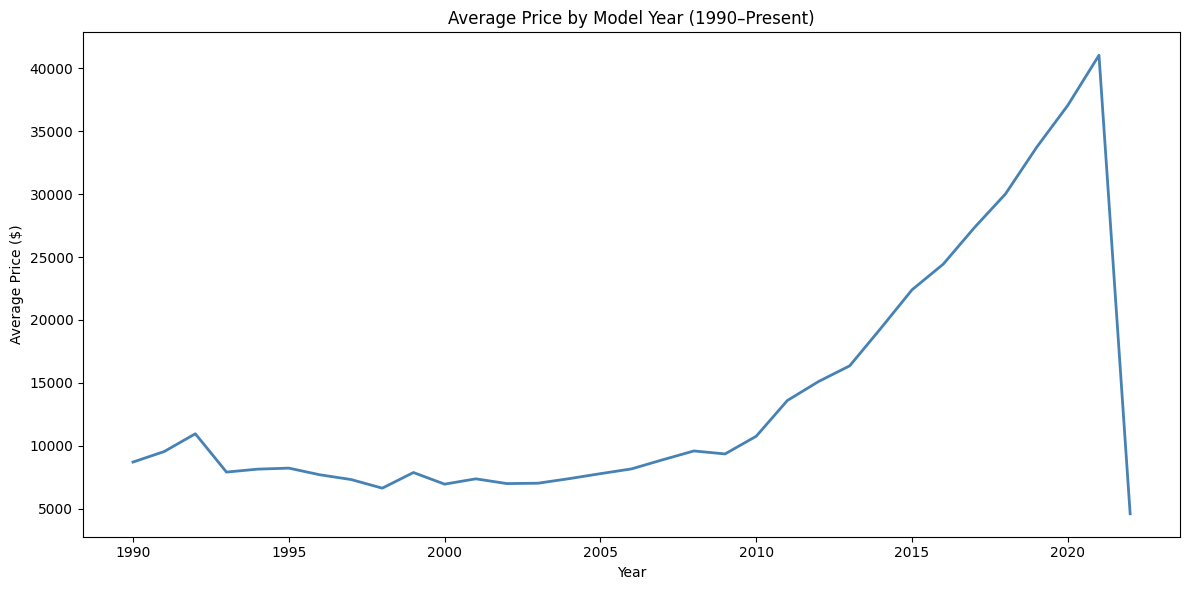

In [13]:
# Filter to realistic years only
avg_price_year = df[df['year'] >= 1990].groupby('year')['price'].mean()

plt.figure(figsize=(12,6))
plt.plot(avg_price_year.index, avg_price_year.values, color='steelblue', linewidth=2)
plt.title('Average Price by Model Year (1990–Present)')
plt.xlabel('Year')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Use year and odometer to predict price
model_df = df[['year', 'odometer', 'price']].dropna()

X = model_df[['year', 'odometer']]
y = model_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.0f}")

R² Score: 0.365
Mean Absolute Error: $8,313


In [15]:
print("=== Key Findings ===")
print(f"Total clean listings analyzed: {len(df):,}")
print(f"Average listing price: ${df['price'].mean():,.0f}")
print(f"Most listed manufacturer: {df['manufacturer'].value_counts().index[0].title()}")
print(f"Price drops per 10k miles: ${abs(model.coef_[1]) * 10000:,.0f}")
print(f"Price increases per newer year: ${model.coef_[0]:,.0f}")

=== Key Findings ===
Total clean listings analyzed: 353,612
Average listing price: $19,155
Most listed manufacturer: Ford
Price drops per 10k miles: $1,104
Price increases per newer year: $378
